# 07 - Modeling: Laptop Price Prediction

This notebook trains and evaluates regression models for laptop price prediction using the fully preprocessed dataset.

Main principles:
- Use one fixed 80/20 train/test split for both targets.
- Never include `price` or `logprice` in the feature matrix.
- Train each model twice: once on `price`, once on `logprice`.
- Convert `logprice` predictions back to the original price scale before the main comparison.
- Save clean artifacts for downstream analysis notebooks.

## 1. Import libraries

Cell này gom các thư viện cần thiết cho toàn bộ quy trình modeling: xử lý dữ liệu, chia tập train/test, huấn luyện mô hình, tính metric, trực quan hóa và lưu artifact. Các warning không quan trọng như `ConvergenceWarning` được ẩn để notebook gọn hơn, nhưng các lỗi train model thật sự vẫn được bắt và in rõ ràng ở phần training.

In [1]:
from __future__ import annotations

import importlib
import pickle
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Configuration

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Choose the inverse transformation used to convert log predictions back to price.
# Use 'log1p' if logprice = np.log1p(price), or 'log' if logprice = np.log(price).
LOG_TRANSFORM = 'log1p'
CLIP_NEGATIVE_PREDICTIONS = True

PROJECT_ROOT = Path.cwd().resolve().parents[1]
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'laptop_processed_numeric.csv'

ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'modeling_numeric'
METRICS_DIR = ARTIFACT_DIR / 'metrics'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
PLOTS_DIR = PROJECT_ROOT / "reports" / "figures" / "modeling_numeric"
MODELS_DIR = ARTIFACT_DIR / 'models'
FEATURE_IMPORTANCE_DIR = ARTIFACT_DIR / 'feature_importance'

for directory in [METRICS_DIR, PREDICTIONS_DIR, PLOTS_DIR, MODELS_DIR, FEATURE_IMPORTANCE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_NAME_FOR_FILE = {
    'Linear Regression': 'LinearRegression',
    'Ridge': 'Ridge',
    'Lasso': 'Lasso',
    'ElasticNet': 'ElasticNet',
    'Random Forest': 'RandomForest',
    'Extra Trees': 'ExtraTrees',
    'XGBoost': 'XGBoost',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
}

print(f'Data path: {DATA_PATH}')
print(f'Artifacts path: {ARTIFACT_DIR}')

Data path: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
Artifacts path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric


## 3. Load preprocessed data

Dữ liệu đầu vào được giả định là bản đã preprocessing hoàn chỉnh, vì vậy notebook không làm lại EDA hay feature engineering. Hàm `standardize_target_columns` chỉ chuẩn hóa tên target về `price` và `logprice`; với file hiện tại, hai cột gốc là `target_price` và `log_target_price`, nên bước này giúp notebook vừa đúng yêu cầu modeling vừa chạy được với schema thực tế.

In [3]:
df = pd.read_csv(DATA_PATH)

required_targets = {'target_price', 'log_target_price'}
missing_targets = required_targets.difference(df.columns)
if missing_targets:
    raise ValueError(f'Missing required target columns: {sorted(missing_targets)}')

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df[['target_price', 'log_target_price']].describe())

Dataset shape: (7208, 77)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,16.0000,256.0000,13.9500,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
1,8.0000,127.0000,15.9500,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,8.0000,512.0000,11.9500,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,32.0000,512.0000,13.9500,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
4,16.0000,256.0000,13.9500,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0


,target_price,log_target_price
count,"7,208.0000","7,208.0000"
mean,15.0088,2.4494
std,15.4028,0.7924
min,1.0000,0.6931
25%,5.6000,1.8871
50%,10.5000,2.4423
75%,18.9000,2.9907
max,179.4000,5.1952


## 4. Define feature matrix and targets

Đây là bước quan trọng nhất để tránh data leakage. Feature matrix `X` được tạo bằng cách loại bỏ cả `price` và `logprice`, còn hai target được giữ riêng biệt: `y_price` dùng cho mô hình dự đoán giá trực tiếp, `y_logprice` dùng cho mô hình học trên log scale. Notebook cũng kiểm tra lại rằng không còn target nào nằm trong `X` trước khi train.

In [4]:
TARGET_COLUMNS = ['target_price', 'log_target_price']

X = df.drop(columns=TARGET_COLUMNS)
y_price = df['target_price']
y_logprice = df['log_target_price']

leakage_columns = {'target_price', 'log_target_price'}.intersection(X.columns)
if leakage_columns:
    raise ValueError(f'Data leakage detected in X: {sorted(leakage_columns)}')

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    raise ValueError(
        'All features should be numeric after preprocessing. '
        f'Non-numeric columns found: {non_numeric_columns}'
    )

feature_names = X.columns.tolist()

print(f'Feature matrix shape: {X.shape}')
print(f'Price target shape: {y_price.shape}')
print(f'Logprice target shape: {y_logprice.shape}')

Feature matrix shape: (7208, 75)
Price target shape: (7208,)
Logprice target shape: (7208,)


## 5. Train/test split 80/20

Cùng một lệnh `train_test_split` được dùng đồng thời cho `X`, `y_price` và `y_logprice`. Cách này đảm bảo mọi model, dù train trên target nào, đều được so sánh trên đúng cùng tập test và cùng các sample, giúp kết quả giữa `price` và `logprice` công bằng hơn.

In [5]:
X_train, X_test, y_price_train, y_price_test, y_log_train, y_log_test = train_test_split(
    X,
    y_price,
    y_logprice,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_price_train: {y_price_train.shape}')
print(f'y_log_train  : {y_log_train.shape}')
print('Same split is used for price and logprice targets.')

X_train: (5766, 75)
X_test : (1442, 75)
y_price_train: (5766,)
y_log_train  : (5766,)
Same split is used for price and logprice targets.


## 6. Define metrics functions

Các metric chính gồm MAE, RMSE, R2, MAPE, Median Absolute Error và Max Error. Với bảng so sánh chính, tất cả metric luôn được tính trên cùng đơn vị là giá laptop thật (`price scale`), vì đây là đơn vị có ý nghĩa trực tiếp nhất khi báo cáo sai số dự đoán.

In [6]:
def calculate_metrics(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Calculate regression metrics on the same scale for y_true and y_pred."""
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)

    return {
        'mae': mean_absolute_error(y_true_arr, y_pred_arr),
        'rmse': root_mean_squared_error(y_true_arr, y_pred_arr),
        'r2': r2_score(y_true_arr, y_pred_arr),
        'mape': mean_absolute_percentage_error(y_true_arr, y_pred_arr),
        'median_ae': median_absolute_error(y_true_arr, y_pred_arr),
        'max_error': max_error(y_true_arr, y_pred_arr),
    }

## 7. Define inverse log transform function

Mô hình train bằng `logprice` sẽ predict ra giá trị trên log scale. Trước khi so sánh với `y_price_test`, prediction này bắt buộc được inverse về price scale bằng `np.expm1` hoặc `np.exp` tùy cấu hình. Notebook cũng clip prediction âm về 0 để tránh các giá trị không hợp lý sau inverse transform.

In [7]:
def inverse_log_transform(y_pred_log: np.ndarray, method: str = 'log1p') -> np.ndarray:
    """Convert log-scale predictions back to price scale."""
    y_pred_log = np.asarray(y_pred_log, dtype=float)

    if method == 'log1p':
        y_pred_price = np.expm1(y_pred_log)
    elif method == 'log':
        y_pred_price = np.exp(y_pred_log)
    else:
        raise ValueError("method must be either 'log1p' or 'log'")

    if CLIP_NEGATIVE_PREDICTIONS:
        y_pred_price = np.maximum(y_pred_price, 0)

    return y_pred_price


def infer_log_transform(y_price_values: pd.Series, y_log_values: pd.Series) -> pd.DataFrame:
    """Quick diagnostic comparing configured transform to observed target values."""
    price = np.asarray(y_price_values, dtype=float)
    log_values = np.asarray(y_log_values, dtype=float)
    diagnostics = pd.DataFrame(
        {
            'method': ['log1p', 'log'],
            'mean_abs_difference': [
                np.mean(np.abs(np.log1p(price) - log_values)),
                np.mean(np.abs(np.log(price) - log_values)),
            ],
        }
    ).sort_values('mean_abs_difference')
    return diagnostics

log_transform_diagnostics = infer_log_transform(y_price, y_logprice)
display(log_transform_diagnostics)
print(f'Configured LOG_TRANSFORM = {LOG_TRANSFORM!r}')

,method,mean_abs_difference
0,log1p,0.0000
1,log,0.1298


Configured LOG_TRANSFORM = 'log1p'


## 8. Define models

Danh sách model được định nghĩa theo một cấu trúc thống nhất gồm tên model, loại model và estimator. Các model tuyến tính được đặt trong pipeline có `StandardScaler` vì chúng nhạy với thang đo feature; các tree-based model không cần scaler. XGBoost, LightGBM và CatBoost là optional: nếu môi trường chưa cài, notebook chỉ cảnh báo và bỏ qua thay vì dừng toàn bộ quy trình.

In [8]:
def optional_import(module_name: str, class_name: str) -> Optional[Any]:
    """Import optional model classes without crashing the notebook."""
    try:
        module = importlib.import_module(module_name)
        return getattr(module, class_name)
    except Exception as exc:
        print(f'Warning: {class_name} is not available and will be skipped. Details: {exc}')
        return None


def make_linear_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ('scaler', StandardScaler()),
            ('model', estimator),
        ]
    )


def define_models() -> List[Dict[str, Any]]:
    models: List[Dict[str, Any]] = [
        {
            'model_name': 'Linear Regression',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(LinearRegression()),
        },
        {
            'model_name': 'Ridge',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Ridge(alpha=1.0)),
        },
        {
            'model_name': 'Lasso',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(Lasso(alpha=0.001, max_iter=10000)),
        },
        {
            'model_name': 'ElasticNet',
            'model_type': 'linear',
            'estimator': make_linear_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)),
        },
        {
            'model_name': 'Random Forest',
            'model_type': 'tree_ensemble',
            'estimator': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
        {
            'model_name': 'Extra Trees',
            'model_type': 'tree_ensemble',
            'estimator': ExtraTreesRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },
    ]

    XGBRegressor = optional_import('xgboost', 'XGBRegressor')
    if XGBRegressor is not None:
        models.append(
            {
                'model_name': 'XGBoost',
                'model_type': 'gradient_boosting',
                'estimator': XGBRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    objective='reg:squarederror',
                    n_jobs=-1,
                ),
            }
        )

    LGBMRegressor = optional_import('lightgbm', 'LGBMRegressor')
    if LGBMRegressor is not None:
        models.append(
            {
                'model_name': 'LightGBM',
                'model_type': 'gradient_boosting',
                'estimator': LGBMRegressor(
                    n_estimators=500,
                    learning_rate=0.05,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            }
        )

    CatBoostRegressor = optional_import('catboost', 'CatBoostRegressor')
    if CatBoostRegressor is not None:
        models.append(
            {
                'model_name': 'CatBoost',
                'model_type': 'gradient_boosting',
                'estimator': CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    random_seed=RANDOM_STATE,
                    verbose=0,
                    allow_writing_files=False,
                ),
            }
        )

    return models


model_specs = define_models()
print(f'Number of models to train: {len(model_specs)}')
print([spec['model_name'] for spec in model_specs])

Number of models to train: 8
['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'Random Forest', 'Extra Trees', 'LightGBM', 'CatBoost']


## Helper functions for training, persistence, plots, and feature importance

Các hàm helper giúp notebook ngắn gọn và dễ bảo trì hơn. Một hàm training duy nhất được dùng cho cả hai target, trong đó logic khác biệt nằm ở bước hậu xử lý prediction: target `price` được dùng trực tiếp, còn target `logprice` được inverse về price scale trước khi tính metric và lưu prediction.

In [9]:
def safe_filename(model_name: str, target_used: str) -> str:
    base_name = MODEL_NAME_FOR_FILE.get(model_name, model_name.replace(' ', ''))
    return f'{base_name}_{target_used}'


def save_model(model: Any, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, path)


def train_and_evaluate_model(
    model: Any,
    model_name: str,
    model_type: str,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test_price: pd.Series,
    target_used: str,
    y_test_log: Optional[pd.Series] = None,
) -> Tuple[Any, Dict[str, Any], np.ndarray, Optional[Dict[str, float]]]:
    """Fit a model and evaluate predictions on price scale."""
    estimator = clone(model)

    start_train = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_time_sec = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    raw_pred = estimator.predict(X_test)
    predict_time_sec = time.perf_counter() - start_pred

    log_scale_metrics = None
    if target_used == 'log_target_price':
        y_pred_price = inverse_log_transform(raw_pred, method=LOG_TRANSFORM)
        if y_test_log is not None:
            log_scale_metrics = calculate_metrics(y_test_log, raw_pred)
    elif target_used == 'target_price':
        y_pred_price = np.asarray(raw_pred, dtype=float)
        if CLIP_NEGATIVE_PREDICTIONS:
            y_pred_price = np.maximum(y_pred_price, 0)
    else:
        raise ValueError("target_used must be 'target_price' or 'log_target_price'")

    metrics = calculate_metrics(y_test_price, y_pred_price)
    metrics.update(
        {
            'model_name': model_name,
            'model_type': model_type,
            'target_used': target_used,
            'evaluation_scale': 'target_price',
            'train_time_sec': train_time_sec,
            'predict_time_sec': predict_time_sec,
        }
    )

    return estimator, metrics, y_pred_price, log_scale_metrics


def plot_metric_comparison(metrics_df: pd.DataFrame, metric_name: str) -> None:
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    plot_df = metrics_df.sort_values(metric_name, ascending=(metric_name != 'r2'))

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=plot_df, x='model_name', y=metric_name, hue='target_used')
    ax.set_title(f'{metric_label} Comparison by Model and Target')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    plt.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{metric_name}_comparison.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_actual_vs_predicted(y_true: pd.Series, y_pred: np.ndarray, model_name: str, target_used: str) -> None:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.55, edgecolor=None)
    min_value = min(np.min(y_true), np.min(y_pred))
    max_value = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--', linewidth=1.5)
    plt.title(f'Actual vs Predicted - {model_name} ({target_used})')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'actual_vs_predicted_{safe_filename(model_name, target_used)}.png', dpi=160, bbox_inches='tight')
    plt.show()


def plot_residuals(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    residuals = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.55,
        edgecolor=None,
        ax=ax
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Residual Plot - {model_name} ({target_used})")
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual: Actual - Predicted")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"residuals_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()


def plot_error_distribution(
    y_true: pd.Series,
    y_pred: np.ndarray,
    model_name: str,
    target_used: str,
    ax=None,
    save: bool = True
) -> None:
    errors = np.asarray(y_true) - np.asarray(y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        show_plot = True
    else:
        fig = ax.figure
        show_plot = False

    sns.histplot(
        errors,
        kde=True,
        bins=40,
        ax=ax
    )

    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"Error Distribution - {model_name} ({target_used})")
    ax.set_xlabel("Prediction Error: Actual - Predicted")
    ax.set_ylabel("Count")

    if show_plot:
        fig.tight_layout()

        if save:
            fig.savefig(
                PLOTS_DIR / f"error_distribution_{safe_filename(model_name, target_used)}.png",
                dpi=160,
                bbox_inches="tight"
            )

        plt.show()

def plot_target_comparison(metrics_df: pd.DataFrame, metric_name: str = 'rmse') -> None:
    comparison_df = metrics_df.pivot(index='model_name', columns='target_used', values=metric_name)
    comparison_df = comparison_df.dropna(how='all').sort_values(by=comparison_df.columns.tolist())

    ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    metric_label = metric_name.upper() if metric_name in ['mae', 'rmse', 'r2', 'mape'] else metric_name
    ax.set_title(f'Price Target vs Logprice Target by Model ({metric_label})')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric_label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(title='Target used')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'target_comparison_{metric_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


def _get_estimator_for_importance(model: Any) -> Any:
    if isinstance(model, Pipeline):
        return model.named_steps.get('model')
    return model


def extract_feature_importance(model: Any, model_name: str, feature_names: List[str]) -> Optional[pd.DataFrame]:
    """Extract feature importances or coefficients when available."""
    fitted_model = _get_estimator_for_importance(model)

    if hasattr(fitted_model, 'feature_importances_'):
        importance = fitted_model.feature_importances_
        importance_type = 'feature_importance'
    elif hasattr(fitted_model, 'coef_'):
        importance = np.ravel(fitted_model.coef_)
        importance_type = 'coefficient'
    else:
        return None

    importance_df = pd.DataFrame(
        {
            'feature': feature_names,
            'importance': importance,
            'abs_importance': np.abs(importance),
            'model_name': model_name,
            'importance_type': importance_type,
        }
    ).sort_values('abs_importance', ascending=False)

    return importance_df

## 9. Train models on `price` and 10. Train models on `logprice`

Vòng lặp training chạy mỗi model hai lần: một lần với target `price`, một lần với target `logprice`. Sau mỗi lần train, notebook lưu model `.pkl`, lưu prediction trên test set, ghi metric chính trên price scale và nếu là log model thì lưu thêm metric phụ trên log scale để tham khảo.

In [10]:
trained_models: Dict[str, Any] = {}
metrics_records: List[Dict[str, Any]] = []
log_scale_metric_records: List[Dict[str, Any]] = []
predictions_df = pd.DataFrame(
    {
        'sample_id': X_test.index,
        'y_true_price': y_price_test.values,
    },
    index=X_test.index,
)

for spec in model_specs:
    model_name = spec['model_name']
    model_type = spec['model_type']
    estimator = spec['estimator']

    for target_used, y_train_current in [('target_price', y_price_train), ('log_target_price', y_log_train)]:
        print(f'Training {model_name} on {target_used}...')
        try:
            fitted_model, metrics, y_pred_price, log_metrics = train_and_evaluate_model(
                model=estimator,
                model_name=model_name,
                model_type=model_type,
                X_train=X_train,
                X_test=X_test,
                y_train=y_train_current,
                y_test_price=y_price_test,
                target_used=target_used,
                y_test_log=y_log_test,
            )
        except Exception as exc:
            print(f'Warning: {model_name} ({target_used}) failed and will be skipped. Details: {exc}')
            continue

        key = f'{model_name}_{target_used}'
        trained_models[key] = fitted_model
        metrics_records.append(metrics)
        predictions_df[f'pred_{safe_filename(model_name, target_used)}'] = y_pred_price

        if log_metrics is not None:
            log_metrics.update(
                {
                    'model_name': model_name,
                    'model_type': model_type,
                    'target_used': target_used,
                    'evaluation_scale': 'log_target_price',
                }
            )
            log_scale_metric_records.append(log_metrics)

        model_path = MODELS_DIR / f'{safe_filename(model_name, target_used)}.pkl'
        save_model(fitted_model, model_path)

print(f'Trained model variants: {len(trained_models)}')

Training Linear Regression on target_price...
Training Linear Regression on log_target_price...
Training Ridge on target_price...
Training Ridge on log_target_price...
Training Lasso on target_price...
Training Lasso on log_target_price...
Training ElasticNet on target_price...
Training ElasticNet on log_target_price...
Training Random Forest on target_price...
Training Random Forest on log_target_price...
Training Extra Trees on target_price...
Training Extra Trees on log_target_price...
Training LightGBM on target_price...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 5766, number of used features: 72
[LightGBM] [Info] Start training from 

## 11. Evaluate all models on price scale

Bảng `metrics_df` là bảng so sánh chính của notebook. Dù model được train bằng target nào, các cột `mae`, `rmse`, `r2`, `mape`, `median_ae` và `max_error` đều phản ánh hiệu năng trên price scale. Vì vậy có thể đọc trực tiếp bảng này để chọn model phục vụ bài toán dự đoán giá.

In [11]:
metrics_df = pd.DataFrame(metrics_records)
metric_columns = [
    'model_name',
    'model_type',
    'target_used',
    'evaluation_scale',
    'mae',
    'rmse',
    'r2',
    'mape',
    'median_ae',
    'max_error',
    'train_time_sec',
    'predict_time_sec',
]
metrics_df = metrics_df[metric_columns].sort_values('rmse').reset_index(drop=True)

display(metrics_df)

if log_scale_metric_records:
    log_metrics_df = pd.DataFrame(log_scale_metric_records)
    display(log_metrics_df.sort_values('rmse').reset_index(drop=True))
else:
    log_metrics_df = pd.DataFrame()

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520
5,Random Forest,tree_ensemble,target_price,target_price,3.5747,5.8937,0.8442,0.3305,1.9434,37.3202,1.8648,0.1742
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7410,6.1857,0.8283,0.3206,2.0445,45.0000,2.1408,0.1710
7,Extra Trees,tree_ensemble,target_price,target_price,3.8199,6.2636,0.8240,0.3471,2.0825,45.0000,1.9662,0.1751
8,Ridge,linear,target_price,target_price,4.3560,6.4143,0.8154,0.4580,2.9109,50.6677,0.1689,0.0061
9,Lasso,linear,target_price,target_price,4.3555,6.4146,0.8154,0.4578,2.9154,50.7307,2.1067,0.0060


,mae,rmse,r2,mape,median_ae,max_error,model_name,model_type,target_used,evaluation_scale
0,0.2304,0.3043,0.8507,0.1123,0.1860,2.0367,CatBoost,gradient_boosting,log_target_price,log_target_price
1,0.2282,0.3050,0.8500,0.1116,0.1778,2.0409,LightGBM,gradient_boosting,log_target_price,log_target_price
2,0.2400,0.3215,0.8334,0.1178,0.1829,1.9052,Random Forest,tree_ensemble,log_target_price,log_target_price
3,0.2528,0.3395,0.8142,0.1232,0.1939,1.8837,Extra Trees,tree_ensemble,log_target_price,log_target_price
4,0.3048,0.3924,0.7517,0.1516,0.2501,1.9006,Ridge,linear,log_target_price,log_target_price
5,0.3048,0.3925,0.7516,0.1518,0.2536,1.9092,ElasticNet,linear,log_target_price,log_target_price
6,0.3050,0.3927,0.7514,0.1520,0.2537,1.9181,Lasso,linear,log_target_price,log_target_price
7,0.3058,0.3938,0.7500,0.1520,0.2528,1.8934,Linear Regression,linear,log_target_price,log_target_price


## Model Evaluation Summary

### Overall Performance

Bảng đầu tiên so sánh hiệu năng của tất cả mô hình trên cùng một thang đo `target_price`. Điều này có nghĩa là các mô hình được huấn luyện với `log_target_price` đã được chuyển ngược về đơn vị giá gốc trước khi tính toán metric. Vì vậy, bảng này là cơ sở quan trọng nhất để đánh giá khả năng dự đoán giá laptop thực tế.

Nhìn chung, nhóm mô hình `gradient_boosting` cho kết quả tốt nhất. Trong đó, `CatBoost` sử dụng trực tiếp `target_price` đạt hiệu năng tốt nhất với MAE khoảng **3.49**, RMSE khoảng **5.51**, và R² khoảng **0.864**. Đây là mô hình có khả năng giải thích biến động giá tốt nhất trong nhóm, đồng thời giữ sai số dự đoán ở mức tương đối thấp.

`CatBoost` với `log_target_price` cũng cho kết quả rất cạnh tranh, với MAE thấp hơn một chút, khoảng **3.43**, nhưng RMSE cao hơn nhẹ, khoảng **5.64**. Điều này cho thấy log-transform giúp giảm sai số tuyệt đối trung bình, nhưng chưa cải thiện rõ rệt về RMSE trên thang giá gốc.

### Target Comparison

Khi so sánh giữa hai cách xây dựng target là `target_price` và `log_target_price`, kết quả cho thấy log-transform mang lại lợi ích nhất định, nhưng không đồng đều cho tất cả mô hình.

Với `CatBoost`, phiên bản dùng `log_target_price` có MAE thấp hơn so với phiên bản dùng `target_price`, cho thấy mô hình dự đoán ổn định hơn ở mức sai số trung bình. Tuy nhiên, RMSE và R² của phiên bản `target_price` lại tốt hơn một chút, cho thấy mô hình trực tiếp trên giá gốc xử lý tốt hơn các sai số lớn.

Với `LightGBM`, mô hình dùng `log_target_price` có MAE thấp hơn phiên bản dùng `target_price`, nhưng RMSE gần như tương đương. Đối với `Random Forest`, log-transform cũng giúp cải thiện nhẹ MAE và RMSE so với target gốc. Tuy nhiên, với nhóm linear models, việc dùng `log_target_price` làm target lại làm hiệu năng trên thang giá gốc giảm mạnh, thể hiện qua RMSE rất cao và R² âm.

### Model Family Comparison

Các mô hình tree-based ensemble, đặc biệt là nhóm `gradient_boosting`, vượt trội hơn rõ rệt so với nhóm linear models. `CatBoost` và `LightGBM` đều đạt RMSE quanh mức **5.5–5.8**, trong khi các mô hình tuyến tính như `Linear Regression`, `Ridge`, `Lasso`, và `ElasticNet` có RMSE khoảng **6.34–6.35** khi train trực tiếp trên `target_price`.

Điều này cho thấy mối quan hệ giữa đặc trưng laptop và giá bán có tính phi tuyến khá rõ. Các mô hình tree-based có khả năng khai thác tốt hơn interaction giữa các feature, chẳng hạn như sự kết hợp giữa CPU, RAM, GPU, brand, storage, screen size và các thông số kỹ thuật khác.

Nhóm `tree_ensemble` như `Random Forest` và `Extra Trees` cũng cho kết quả tốt hơn linear models, nhưng vẫn thấp hơn nhóm boosting. Điều này cho thấy boosting models phù hợp hơn với bài toán hiện tại do khả năng học tuần tự và giảm lỗi qua từng vòng lặp.

### Linear Models

Nhóm linear models có hiệu năng thấp hơn so với tree-based models. Khi sử dụng trực tiếp `target_price`, các mô hình linear đạt R² khoảng **0.819**, thấp hơn đáng kể so với `CatBoost` và `LightGBM`.

Khi sử dụng `log_target_price`, hiệu năng của linear models trên thang giá gốc giảm rất mạnh. Các mô hình như `Linear Regression`, `Ridge`, `Lasso`, và `ElasticNet` có RMSE lên tới khoảng **29–30** và R² âm. Điều này cho thấy các dự đoán sau khi chuyển ngược từ log scale về giá gốc bị sai lệch lớn, đặc biệt ở các quan sát có giá trị cao.

Vì vậy, linear models chỉ nên được xem là baseline đơn giản. Chúng có thể hữu ích để tham khảo xu hướng tổng quát hoặc kiểm tra mức độ tuyến tính của dữ liệu, nhưng không phải là lựa chọn phù hợp nhất nếu mục tiêu chính là tối ưu hiệu năng dự đoán.

### Log Scale Evaluation

Bảng thứ hai đánh giá riêng các mô hình được train trên `log_target_price` và tính metric trực tiếp trên log scale. Trên thang đo này, `CatBoost` tiếp tục là mô hình tốt nhất, với MAE khoảng **0.229**, RMSE khoảng **0.304**, và R² khoảng **0.852**.

`LightGBM` đứng thứ hai với kết quả rất gần, đạt MAE khoảng **0.228**, RMSE khoảng **0.305**, và R² khoảng **0.850**. `Random Forest` và `Extra Trees` có hiệu năng thấp hơn một chút, trong khi nhóm linear models tiếp tục kém hơn đáng kể.

Kết quả trên log scale cho thấy `CatBoost` và `LightGBM` đều học tốt khi target được log-transform. Sai số thấp trên log scale cũng cho thấy các mô hình này dự đoán tương đối ổn theo tỷ lệ phần trăm, không chỉ theo sai số tuyệt đối trên thang giá gốc.

### Error Pattern

Mặc dù các mô hình tốt nhất có MAE chỉ khoảng **3.4–3.5**, giá trị `max_error` vẫn khá cao, dao động khoảng **36–40** đối với nhóm top models. Điều này cho thấy vẫn tồn tại một số mẫu laptop mà mô hình dự đoán sai lệch lớn.

Các sai số lớn này có thể đến từ các dòng laptop cao cấp, cấu hình đặc biệt, giá bán bất thường, hoặc các outlier trong dữ liệu. Ngoài ra, một số thông tin quan trọng như tình trạng máy, năm sản xuất, phân khúc sản phẩm, dòng CPU/GPU chi tiết hoặc yếu tố thương hiệu có thể chưa được biểu diễn đầy đủ trong feature set.

Ở bước tiếp theo, nên phân tích các observation có residual lớn để xác định nguyên nhân sai số, từ đó quyết định có cần xử lý outlier, bổ sung feature, cải thiện encoding hoặc tách riêng các phân khúc giá hay không.

### Training Time

Thời gian huấn luyện của hầu hết mô hình đều khá thấp. `LightGBM` có tốc độ train nhanh trong nhóm boosting, chỉ khoảng **2 giây**, trong khi `CatBoost` mất khoảng **7–9 giây** tùy target. Mặc dù `CatBoost` chậm hơn `LightGBM`, thời gian này vẫn hoàn toàn chấp nhận được với kích thước dữ liệu hiện tại.

Các mô hình tuyến tính có thời gian train rất thấp, nhưng hiệu năng không cạnh tranh với nhóm tree-based models. `Random Forest` có thời gian dự đoán cao hơn đáng kể so với các mô hình khác, trong khi performance cũng không vượt trội.

Do đó, ở giai đoạn hiện tại, hiệu năng dự đoán nên được ưu tiên hơn training time. `CatBoost` và `LightGBM` là hai mô hình nên được giữ lại cho các bước feature selection, hyperparameter tuning và model interpretation tiếp theo.

### Key Takeaways

`CatBoost` hiện là mô hình baseline tốt nhất trên thang giá gốc, đặc biệt khi xét tổng thể giữa RMSE, MAE và R². Phiên bản dùng `target_price` có RMSE và R² tốt nhất, trong khi phiên bản dùng `log_target_price` có MAE tốt hơn một chút.

`LightGBM` cũng là một ứng viên rất mạnh, với hiệu năng gần sát `CatBoost` nhưng thời gian huấn luyện nhanh hơn. Các mô hình tree-based ensemble nhìn chung phù hợp hơn linear models cho bài toán dự đoán giá laptop, do dữ liệu có quan hệ phi tuyến và nhiều tương tác giữa các đặc trưng.

Notebook này nên được xem là bước baseline modeling để xác định nhóm mô hình tiềm năng. Trong các bước tiếp theo, nên tập trung vào `CatBoost` và `LightGBM`, đồng thời thực hiện thêm hyperparameter tuning, phân tích feature importance, kiểm tra residual và đánh giá mô hình trên các phân khúc giá khác nhau.

## 12. Save metrics

Metrics được lưu thành CSV để các notebook phân tích tiếp theo có thể đọc lại mà không cần train lại model. File `model_metrics.csv` là artifact chính; file `log_scale_model_metrics.csv` chỉ là metric phụ cho nhóm model train bằng `logprice`.

In [12]:
metrics_path = METRICS_DIR / 'model_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved main metrics to: {metrics_path}')

if not log_metrics_df.empty:
    log_metrics_path = METRICS_DIR / 'log_scale_model_metrics.csv'
    log_metrics_df.to_csv(log_metrics_path, index=False)
    print(f'Saved optional log-scale metrics to: {log_metrics_path}')

Saved main metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
Saved optional log-scale metrics to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\log_scale_model_metrics.csv


## 13. Save predictions

File prediction giữ `sample_id`, giá thật và prediction của từng biến thể model. Cấu trúc wide-format này tiện cho các phân tích sau như residual analysis, so sánh từng sample, tìm nhóm laptop có sai số lớn, hoặc tạo ensemble từ nhiều model.

In [13]:
predictions_path = PREDICTIONS_DIR / 'test_predictions.csv'
predictions_df.reset_index(drop=True).to_csv(predictions_path, index=False)
print(f'Saved test predictions to: {predictions_path}')
display(predictions_df.head())

Saved test predictions to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
308,308,9.0000,9.6641,7.5611,9.6946,7.5296,9.6908,7.6658,9.6976,7.6043,6.7468,6.2711,6.9308,6.4150,6.9120,6.5745,8.7198,6.9512
381,381,10.5000,10.6328,8.0600,10.4302,7.9252,10.4369,7.8958,10.4315,7.9140,9.0842,8.8218,9.0997,8.8671,9.1409,8.7900,8.9843,8.5053
1839,1839,2.0000,4.6875,5.6674,4.6735,5.8175,4.6646,5.8844,4.6578,5.8550,2.8033,2.7044,3.1748,2.8450,3.7969,3.3711,3.8885,3.5125
3438,3438,11.5000,13.9141,13.7706,13.8621,13.2717,13.8765,13.0689,13.8730,13.1694,12.8945,12.6684,12.8956,12.6720,13.4430,13.5301,13.0165,13.0666
251,251,9.2000,10.0234,8.0423,10.2500,8.1516,10.2458,8.0850,10.2675,8.1148,8.2383,7.6625,10.1611,6.7065,9.5467,9.0143,9.2180,8.5379


## 14. Save trained models

Mỗi model đã train được lưu riêng theo tên rõ ràng gồm model name và target đã dùng. Điều này giúp load lại đúng biến thể model khi cần inference hoặc phân tích feature importance mà không phải chạy lại notebook.

In [14]:
model_files = sorted(MODELS_DIR.glob('*.pkl'))
print(f'Saved {len(model_files)} model files to: {MODELS_DIR}')
for path in model_files:
    print(path.name)

Saved 16 model files to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\models
CatBoost_log_target_price.pkl
CatBoost_target_price.pkl
ElasticNet_log_target_price.pkl
ElasticNet_target_price.pkl
ExtraTrees_log_target_price.pkl
ExtraTrees_target_price.pkl
Lasso_log_target_price.pkl
Lasso_target_price.pkl
LightGBM_log_target_price.pkl
LightGBM_target_price.pkl
LinearRegression_log_target_price.pkl
LinearRegression_target_price.pkl
RandomForest_log_target_price.pkl
RandomForest_target_price.pkl
Ridge_log_target_price.pkl
Ridge_target_price.pkl


## 15. Generate comparison plots

Các biểu đồ so sánh MAE, RMSE và R2 giúp nhìn nhanh trade-off giữa model và target. Biểu đồ so sánh `price` vs `logprice` theo từng model đặc biệt hữu ích để trả lời câu hỏi: cùng một thuật toán, học trên target nào tốt hơn khi đánh giá trên đơn vị giá thật?

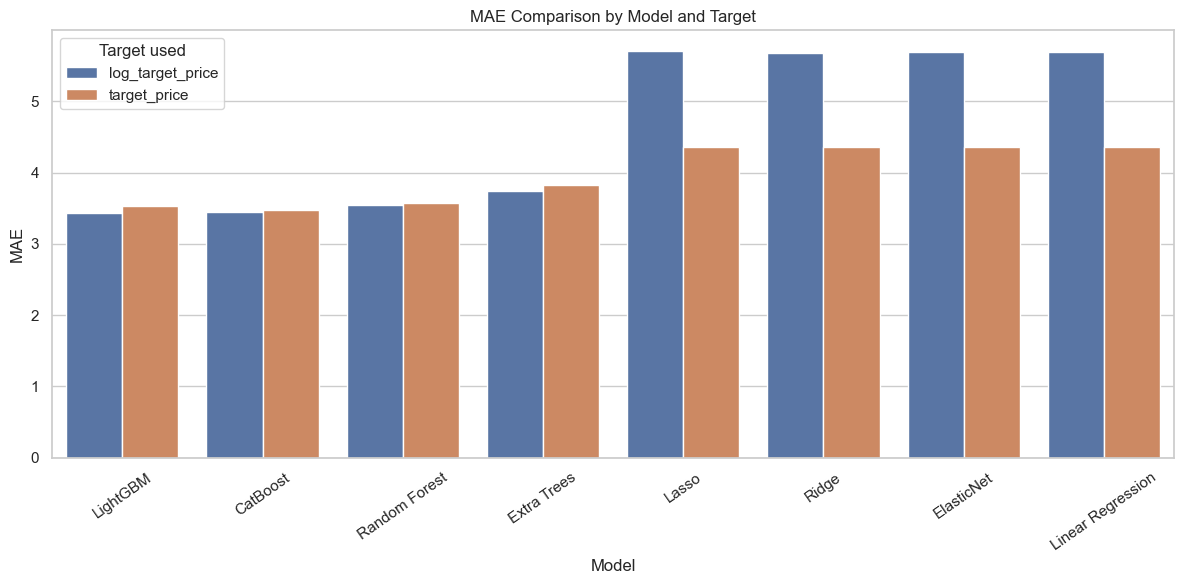

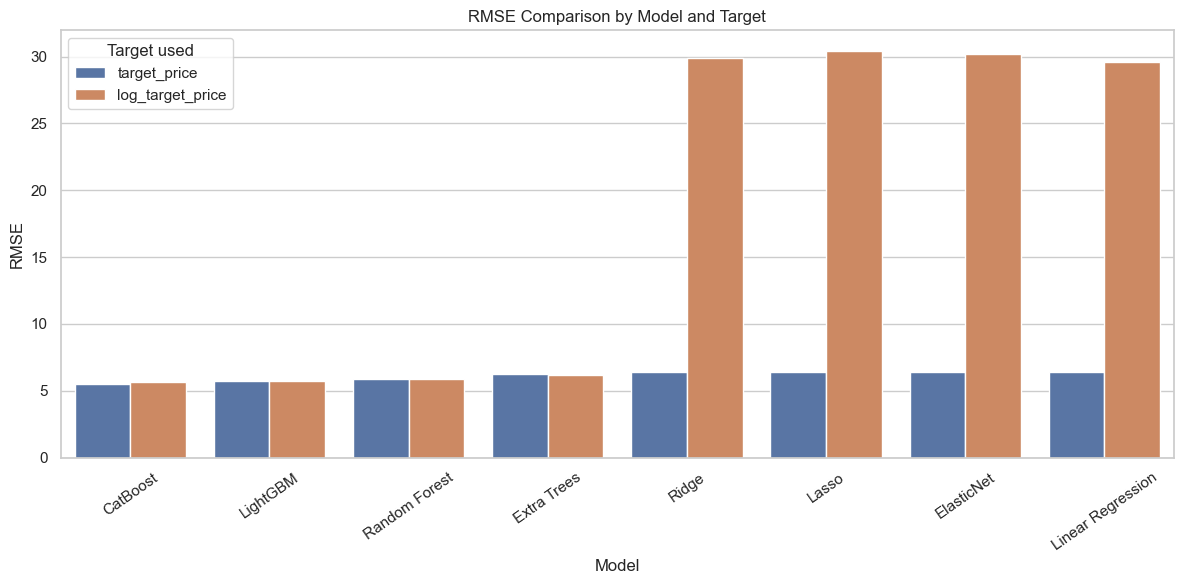

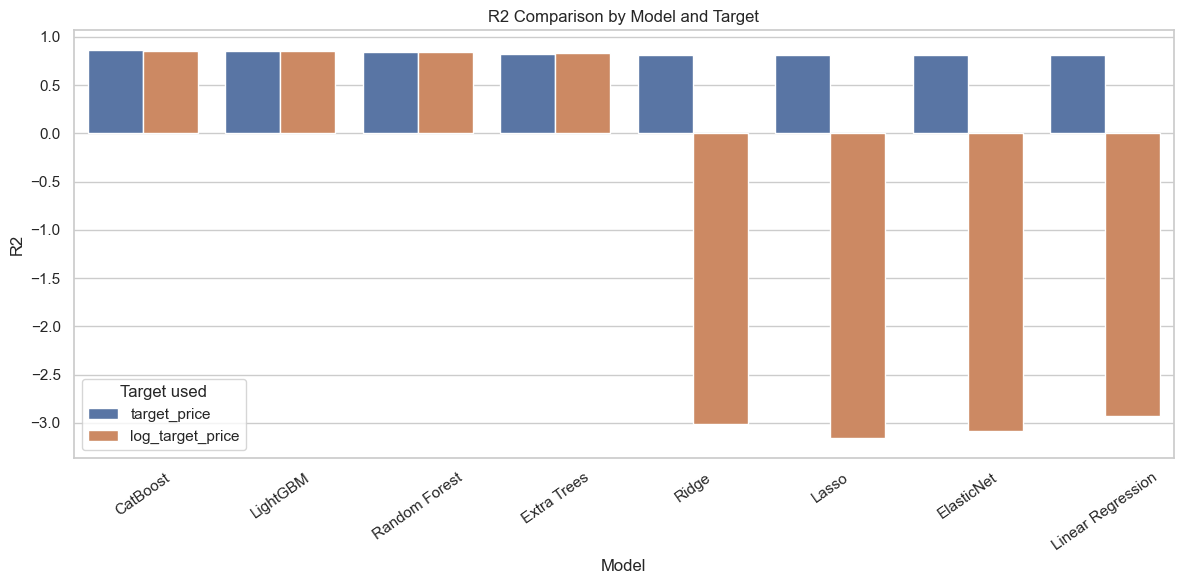

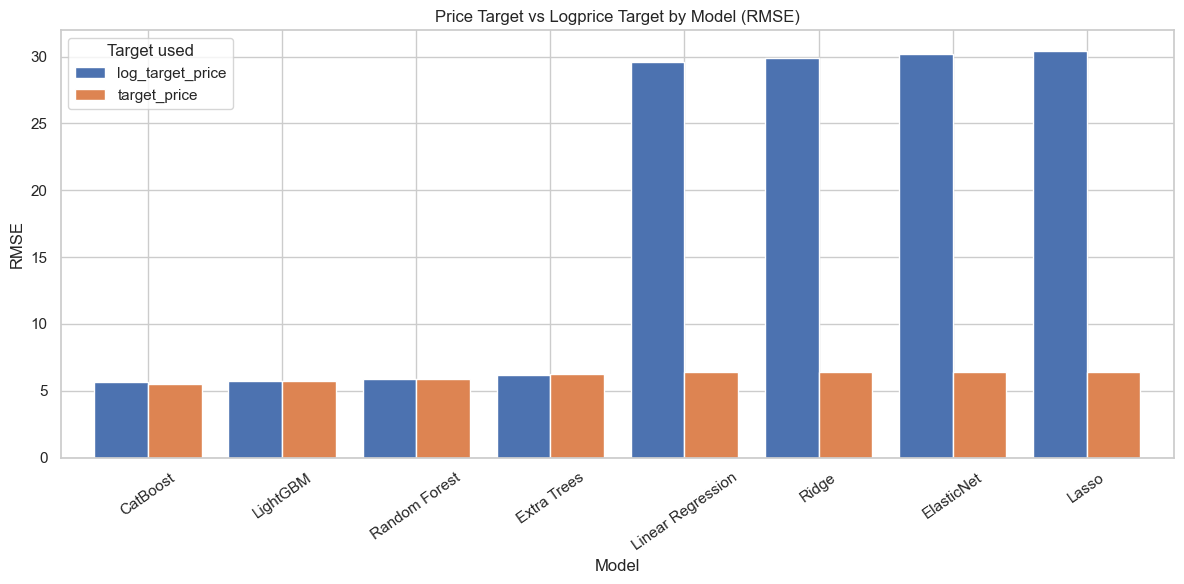

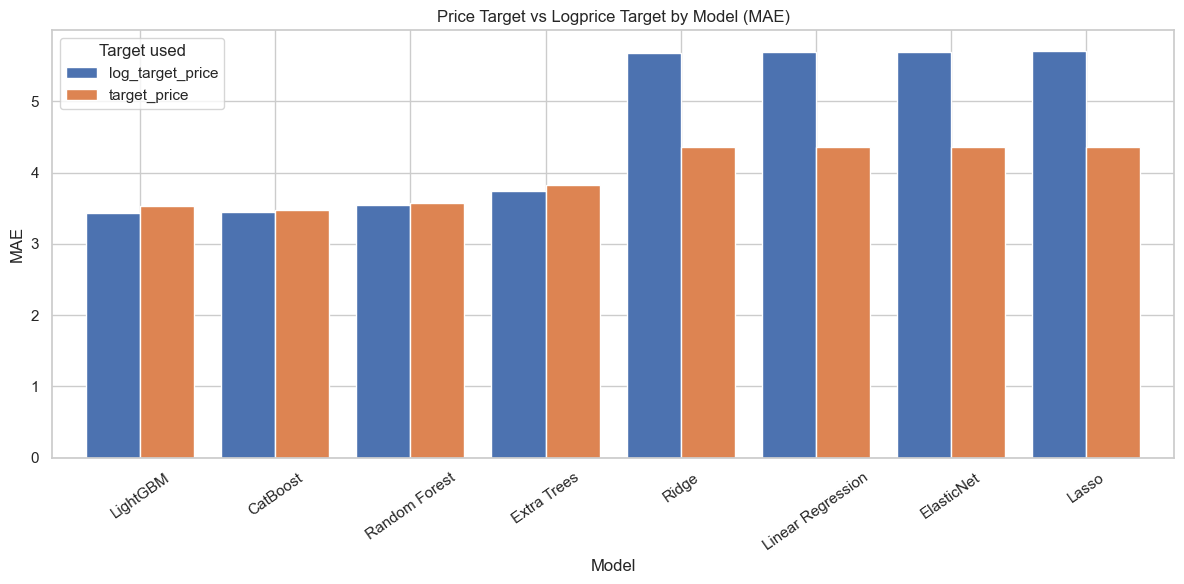

In [15]:
for metric in ['mae', 'rmse', 'r2']:
    plot_metric_comparison(metrics_df, metric)

plot_target_comparison(metrics_df, metric_name='rmse')
plot_target_comparison(metrics_df, metric_name='mae')

## Target Strategy Comparison

Các biểu đồ trên so sánh hiệu năng của từng mô hình khi sử dụng hai chiến lược target khác nhau: train trực tiếp trên `target_price` và train trên `log_target_price`, sau đó chuyển prediction ngược về thang giá gốc để đánh giá. Vì các metric như MAE, RMSE và R² đều được tính trên cùng thang đo `target_price`, kết quả giữa hai chiến lược có thể được so sánh trực tiếp.

Nhìn chung, nhóm mô hình tree-based, đặc biệt là `CatBoost`, `LightGBM`, `Random Forest` và `Extra Trees`, cho kết quả ổn định hơn so với nhóm linear models. Các mô hình này duy trì MAE và RMSE thấp, đồng thời đạt R² cao trong cả hai cách biểu diễn target. Điều này cho thấy các mô hình dạng cây phù hợp hơn với bài toán dự đoán giá laptop, vốn có nhiều quan hệ phi tuyến giữa đặc trưng cấu hình và giá bán.

### MAE Comparison

Xét theo MAE, các mô hình boosting như `CatBoost` và `LightGBM` có sai số trung bình thấp nhất. Với `CatBoost`, phiên bản sử dụng `log_target_price` cho MAE thấp hơn một chút so với phiên bản train trực tiếp trên `target_price`. Điều này cho thấy log-transform có thể giúp mô hình giảm sai số tuyệt đối trung bình.

Tuy nhiên, mức chênh lệch giữa hai chiến lược target ở nhóm tree-based models không quá lớn. `LightGBM`, `Random Forest` và `Extra Trees` cũng có xu hướng tương tự: khi dùng `log_target_price`, MAE có thể giảm nhẹ, nhưng sự cải thiện không đủ lớn để tạo ra khác biệt rõ rệt về tổng thể.

Ngược lại, ở nhóm linear models như `Linear Regression`, `Ridge`, `Lasso` và `ElasticNet`, việc sử dụng `log_target_price` làm target khiến MAE trên thang giá gốc tăng đáng kể. Điều này cho thấy các mô hình tuyến tính không xử lý tốt việc học trên log target rồi chuyển ngược về giá gốc trong bài toán này.

### RMSE Comparison

Biểu đồ RMSE cho thấy sự khác biệt rõ hơn giữa các nhóm mô hình. Với các mô hình tree-based, RMSE giữa `target_price` và `log_target_price` khá gần nhau. `CatBoost` và `LightGBM` vẫn là hai mô hình có RMSE thấp nhất, cho thấy khả năng kiểm soát các sai số lớn tốt hơn so với các mô hình còn lại.

Đối với `CatBoost`, phiên bản train trực tiếp trên `target_price` có RMSE thấp hơn nhẹ so với phiên bản dùng `log_target_price`. Điều này cho thấy mặc dù log-transform giúp giảm MAE, nhưng chưa chắc cải thiện RMSE, vì RMSE nhạy hơn với các lỗi dự đoán lớn.

Sự khác biệt lớn nhất xuất hiện ở nhóm linear models. Khi train trên `log_target_price`, RMSE của các mô hình tuyến tính tăng rất mạnh, cao hơn nhiều so với khi train trực tiếp trên `target_price`. Điều này cho thấy sau khi inverse-transform từ log scale về giá gốc, các dự đoán của linear models có thể bị lệch lớn ở một số quan sát, đặc biệt là các laptop có giá cao hoặc nằm ngoài phân phối phổ biến.

### R² Comparison

Biểu đồ R² tiếp tục củng cố nhận xét trên. Các mô hình tree-based duy trì R² cao trong cả hai chiến lược target, cho thấy chúng giải thích được phần lớn biến động của giá laptop. `CatBoost` và `LightGBM` là hai mô hình có R² cao nhất, thể hiện khả năng mô hình hóa tốt quan hệ giữa các feature và giá bán.

Trong khi đó, nhóm linear models có R² tương đối ổn khi train trực tiếp trên `target_price`, nhưng giảm mạnh khi sử dụng `log_target_price`. Một số mô hình tuyến tính thậm chí có R² âm sau khi chuyển prediction về thang giá gốc. Điều này cho thấy mô hình còn kém hơn cả việc dự đoán bằng giá trị trung bình, nên không phù hợp để sử dụng với chiến lược log-target trong bài toán này.

### Model-wise Observation

`CatBoost` là mô hình ổn định nhất giữa hai chiến lược target. Phiên bản `log_target_price` có MAE thấp hơn nhẹ, trong khi phiên bản `target_price` có RMSE và R² tốt hơn một chút. Vì vậy, cả hai phiên bản đều đáng được giữ lại để thử nghiệm sâu hơn ở bước tuning.

`LightGBM` cũng là một ứng viên mạnh, với hiệu năng gần sát `CatBoost`. Mô hình này có ưu điểm là tốc độ train nhanh và kết quả ổn định, nên phù hợp để dùng trong các vòng thử nghiệm feature engineering hoặc hyperparameter tuning.

`Random Forest` và `Extra Trees` có kết quả thấp hơn nhóm boosting nhưng vẫn tốt hơn linear models. Các mô hình này có thể dùng làm baseline mạnh cho nhóm tree ensemble, tuy nhiên chưa phải lựa chọn tối ưu nếu xét theo RMSE và R².

Nhóm linear models chỉ nên được xem là baseline tham khảo. Khi train trực tiếp trên `target_price`, chúng vẫn cho kết quả chấp nhận được ở mức cơ bản, nhưng khi dùng `log_target_price`, hiệu năng giảm rất mạnh trên thang giá gốc.

### Key Takeaways

Tổng thể, `CatBoost` và `LightGBM` là hai mô hình tiềm năng nhất cho bài toán dự đoán giá laptop. Hai mô hình này đạt sai số thấp, R² cao và duy trì hiệu năng ổn định giữa hai chiến lược target.

Việc sử dụng `log_target_price` có thể giúp giảm MAE nhẹ ở một số mô hình tree-based, đặc biệt là `CatBoost`, nhưng không nhất thiết cải thiện RMSE hoặc R². Vì vậy, log-transform nên được xem là một hướng thử nghiệm có giá trị, thay vì mặc định là lựa chọn tốt hơn trong mọi trường hợp.

Đối với bước tiếp theo, nên ưu tiên tuning `CatBoost` và `LightGBM` với cả hai target strategy. Sau đó, lựa chọn mô hình cuối cùng nên dựa trên sự cân bằng giữa MAE, RMSE, R² và phân tích residual, đặc biệt ở các phân khúc laptop có giá cao hoặc cấu hình đặc biệt.

## 16. Generate actual vs predicted plots for top 3 models

Scatter plot Actual vs Predicted cho top 3 model giúp kiểm tra trực quan mức độ bám sát đường lý tưởng `y = x`. Nếu điểm lệch mạnh ở vùng giá cao hoặc giá thấp, đó là dấu hiệu nên phân tích thêm theo phân khúc laptop thay vì chỉ nhìn metric tổng thể.

,model_name,target_used,rmse,mae,r2
0,CatBoost,target_price,5.4785,3.4705,0.8653
1,CatBoost,log_target_price,5.6434,3.4455,0.8571
2,LightGBM,target_price,5.7620,3.5269,0.8511


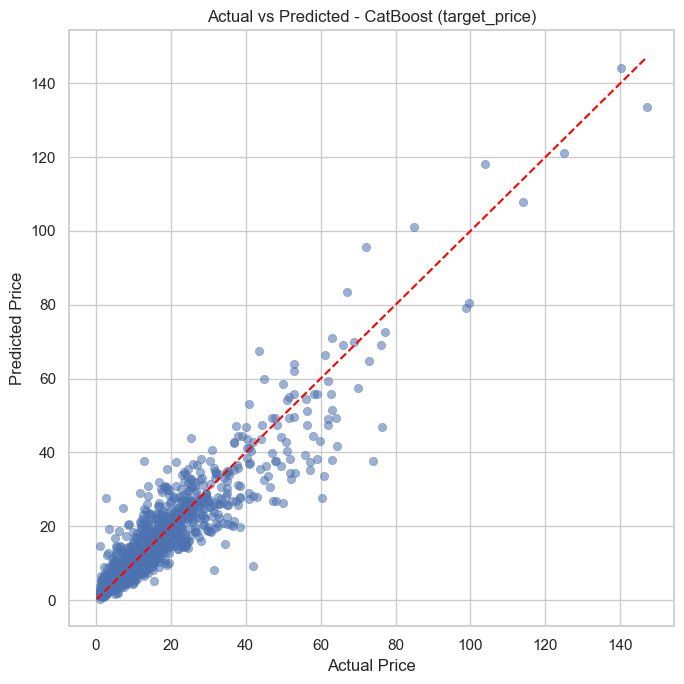

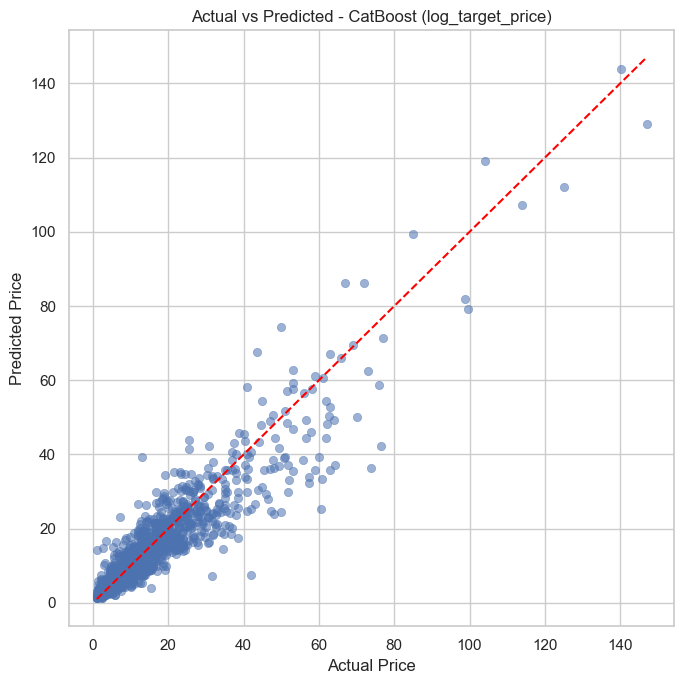

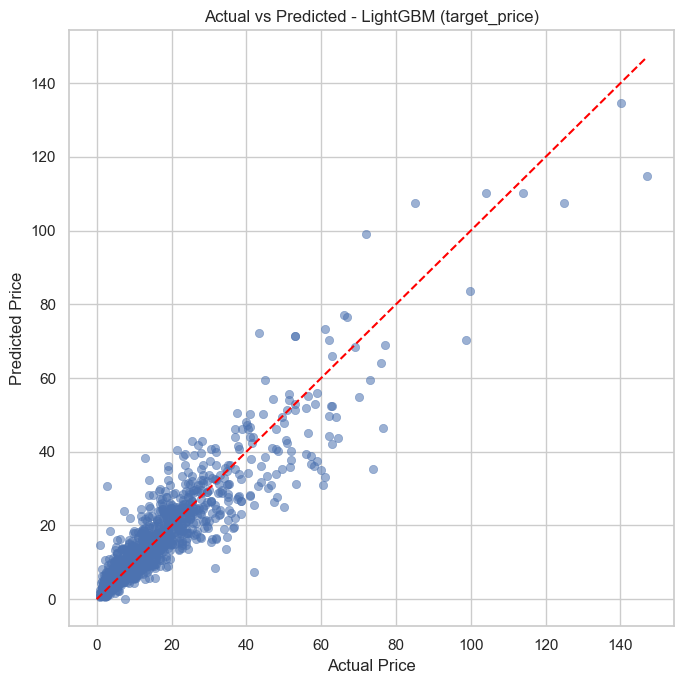

In [16]:
top_3_models = metrics_df.sort_values('rmse').head(3)[['model_name', 'target_used', 'rmse', 'mae', 'r2']]
display(top_3_models)

for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    plot_actual_vs_predicted(
        y_true=y_price_test,
        y_pred=predictions_df[pred_col].values,
        model_name=row['model_name'],
        target_used=row['target_used'],
    )

## Actual vs Predicted Analysis

Các biểu đồ trên thể hiện mối quan hệ giữa giá trị thực tế (`Actual Price`) và giá trị dự đoán (`Predicted Price`) của các mô hình tốt nhất. Đường gạch đỏ biểu diễn đường lý tưởng `y = x`, tức là điểm dự đoán hoàn hảo khi giá trị predicted bằng đúng giá trị actual. Các điểm càng nằm gần đường này thì mô hình dự đoán càng chính xác.

Nhìn chung, cả ba mô hình đều cho thấy xu hướng dự đoán khá tốt. Phần lớn các điểm dữ liệu tập trung quanh đường chéo đỏ, đặc biệt ở vùng giá thấp và trung bình. Điều này cho thấy mô hình học được tương đối tốt mối quan hệ giữa các đặc trưng laptop và giá bán thực tế.

### CatBoost with `target_price`

Biểu đồ của `CatBoost` khi train trực tiếp trên `target_price` cho thấy các điểm dự đoán bám khá sát đường lý tưởng. Ở vùng giá thấp đến trung bình, phần lớn điểm nằm gần đường `y = x`, cho thấy mô hình dự đoán khá chính xác đối với nhóm laptop phổ biến trong dữ liệu.

Tuy nhiên, khi giá thực tế tăng cao, độ phân tán của các điểm cũng tăng lên. Một số điểm nằm khá xa đường chéo, cho thấy mô hình vẫn gặp khó khăn với các laptop có giá cao hoặc cấu hình đặc biệt. Đây có thể là nguyên nhân khiến `max_error` vẫn còn tương đối lớn dù MAE và RMSE nhìn chung khá tốt.

### CatBoost with `log_target_price`

Với `CatBoost` sử dụng `log_target_price`, phân bố điểm nhìn khá tương đồng với phiên bản train trực tiếp trên `target_price`. Các điểm ở vùng giá thấp và trung bình vẫn bám sát đường lý tưởng, cho thấy log-transform không làm giảm khả năng dự đoán ở nhóm giá phổ biến.

Một điểm đáng chú ý là mô hình này có xu hướng dự đoán ổn định hơn ở vùng giá thấp và trung bình. Điều này phù hợp với kết quả metric trước đó, khi `CatBoost` dùng `log_target_price` có MAE thấp hơn nhẹ. Tuy nhiên, ở vùng giá cao, vẫn xuất hiện một số điểm bị dự đoán thấp hơn hoặc cao hơn đáng kể so với giá thực tế.

Điều này cho thấy log-transform có thể giúp giảm sai số trung bình, nhưng chưa giải quyết hoàn toàn vấn đề dự đoán các mẫu có giá trị lớn hoặc outlier.

### LightGBM with `log_target_price`

Biểu đồ của `LightGBM` với `log_target_price` cũng cho thấy mô hình dự đoán khá tốt, đặc biệt ở vùng giá thấp và trung bình. Phần lớn các điểm dữ liệu vẫn tập trung quanh đường chéo đỏ, cho thấy mô hình nắm bắt được xu hướng chung của giá laptop.

Tuy nhiên, so với `CatBoost`, các điểm của `LightGBM` có vẻ phân tán hơn một chút ở một số vùng giá trung bình đến cao. Một số mẫu có actual price cao bị dự đoán thấp hơn đáng kể, cho thấy mô hình có thể chưa xử lý tốt các laptop thuộc phân khúc cao cấp hoặc các cấu hình ít xuất hiện trong tập dữ liệu.

Dù vậy, `LightGBM` vẫn là một mô hình mạnh, với hiệu năng gần sát `CatBoost` và có lợi thế về tốc độ huấn luyện.

### Error Pattern Observation

Một xu hướng chung ở cả ba biểu đồ là sai số tăng dần khi giá thực tế tăng. Ở vùng giá thấp, các điểm tập trung dày và gần đường lý tưởng hơn. Trong khi đó, ở vùng giá cao, số lượng điểm ít hơn và độ lệch khỏi đường `y = x` lớn hơn.

Điều này cho thấy mô hình dự đoán tốt hơn đối với các laptop thuộc phân khúc phổ thông hoặc trung cấp, nơi dữ liệu có nhiều quan sát hơn. Ngược lại, các laptop cao cấp có thể khó dự đoán hơn do số lượng mẫu ít, cấu hình đa dạng hơn, hoặc tồn tại các yếu tố giá trị chưa được biểu diễn đầy đủ trong feature set.

Một số điểm nằm phía dưới đường chéo đỏ cho thấy mô hình đang dự đoán thấp hơn giá thực tế. Đây thường là các trường hợp laptop có giá cao nhưng mô hình chưa đánh giá đúng mức giá trị. Ngược lại, các điểm nằm phía trên đường chéo cho thấy mô hình dự đoán cao hơn giá thực tế, có thể xảy ra với các mẫu có cấu hình tốt nhưng giá bán thực tế thấp hơn kỳ vọng.

### Key Takeaways

Các biểu đồ actual vs predicted cho thấy `CatBoost` và `LightGBM` đều có khả năng dự đoán tốt, đặc biệt ở nhóm laptop có giá thấp đến trung bình. `CatBoost` nhìn chung cho kết quả ổn định hơn, với các điểm dự đoán bám sát đường lý tưởng hơn ở nhiều vùng giá.

Tuy nhiên, cả ba mô hình vẫn gặp khó khăn ở phân khúc giá cao, nơi sai số có xu hướng lớn hơn. Đây là điểm cần được phân tích thêm trong các bước tiếp theo, đặc biệt thông qua residual analysis và kiểm tra các observation có error lớn.

Để cải thiện mô hình, nên tiếp tục phân tích các mẫu bị dự đoán sai nhiều, bổ sung hoặc tinh chỉnh feature liên quan đến phân khúc sản phẩm, dòng CPU/GPU, thương hiệu, năm sản xuất và các yếu tố cấu hình cao cấp. Ngoài ra, có thể cân nhắc đánh giá riêng mô hình theo từng phân khúc giá để hiểu rõ hơn hiệu năng của mô hình trên từng nhóm laptop.

## 17. Generate residual and error distribution plots for top 3 models

Residual plot cho biết sai số có phân bố ngẫu nhiên hay bị lệch theo mức giá dự đoán. Error distribution plot giúp quan sát bias tổng thể: phân phối centered gần 0 là tốt, còn lệch hẳn sang một phía cho thấy model có xu hướng overestimate hoặc underestimate.

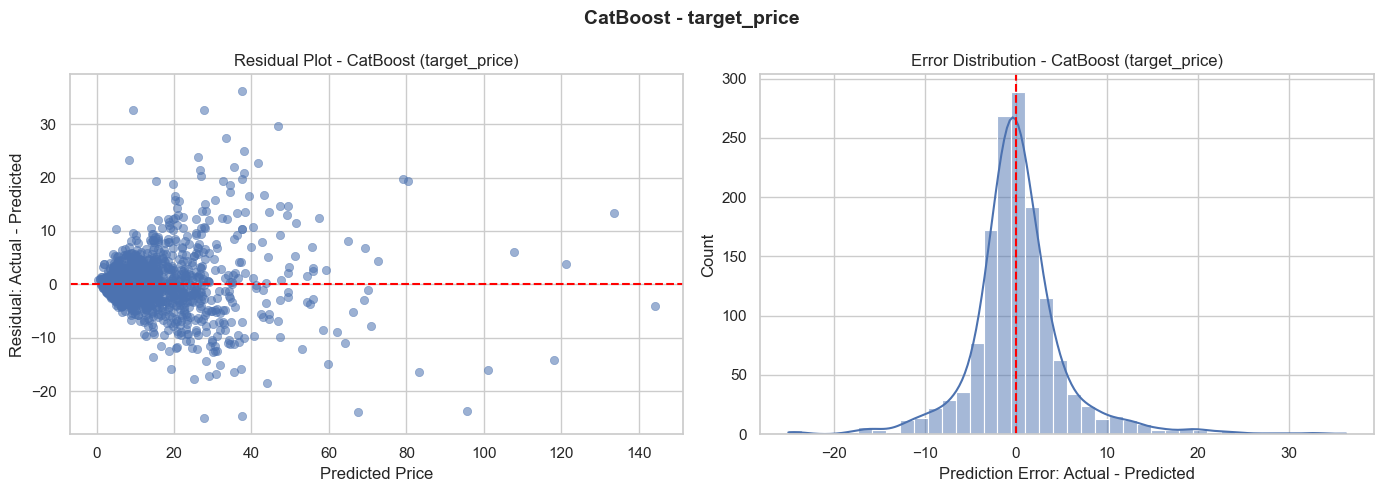

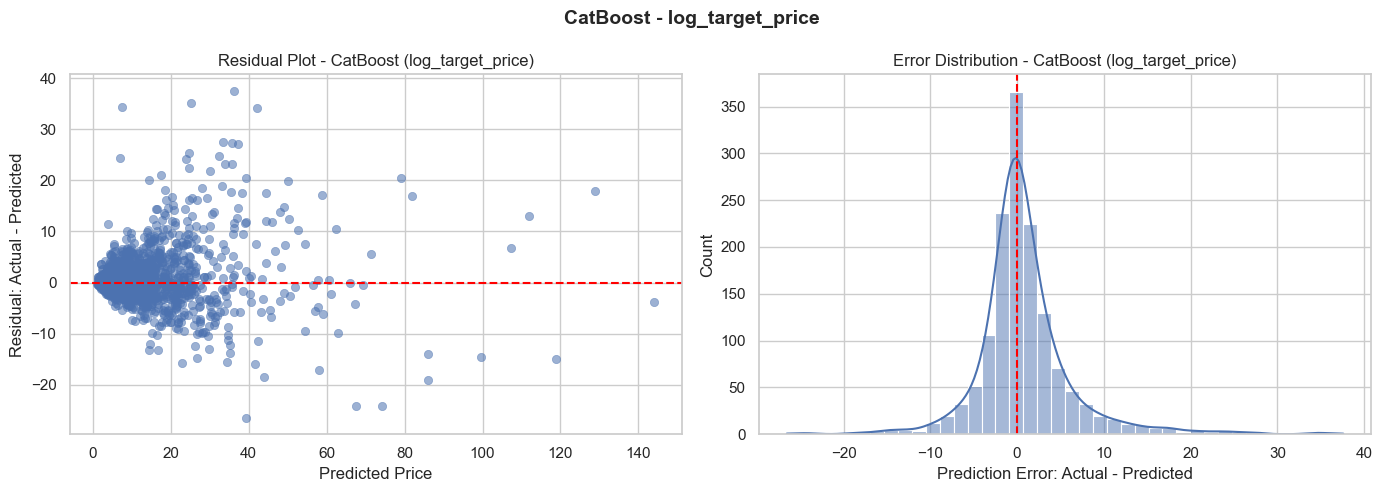

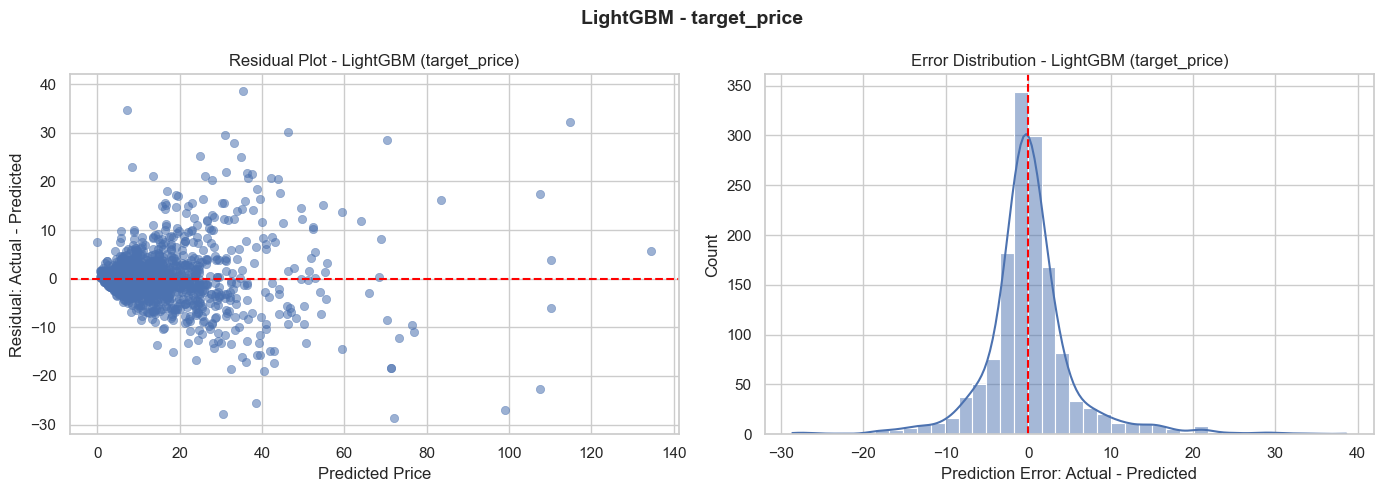

In [17]:
for _, row in top_3_models.iterrows():
    pred_col = f"pred_{safe_filename(row['model_name'], row['target_used'])}"
    y_pred_current = predictions_df[pred_col].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_residuals(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[0]
    )

    plot_error_distribution(
        y_true=y_price_test,
        y_pred=y_pred_current,
        model_name=row['model_name'],
        target_used=row['target_used'],
        ax=axes[1]
    )

    fig.suptitle(
        f"{row['model_name']} - {row['target_used']}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

## 18. Save feature importance / coefficients

Với tree-based model, notebook lưu `feature_importances_`; với linear model, notebook lưu coefficient table. Cột `abs_importance` hỗ trợ sắp xếp độ ảnh hưởng tuyệt đối, nhưng khi diễn giải linear coefficient vẫn nên chú ý dấu âm/dương của cột `importance`.

In [18]:
feature_importance_frames = []

for model_key, fitted_model in trained_models.items():
    model_name, target_used = model_key.rsplit('_', 1)
    importance_df = extract_feature_importance(fitted_model, model_name, feature_names)

    if importance_df is None:
        print(f'No feature importance or coefficients available for {model_key}.')
        continue

    importance_df['target_used'] = target_used
    output_columns = ['feature', 'importance', 'model_name', 'target_used', 'importance_type', 'abs_importance']
    importance_df = importance_df[output_columns]

    output_path = FEATURE_IMPORTANCE_DIR / f'{safe_filename(model_name, target_used)}_feature_importance.csv'
    importance_df.to_csv(output_path, index=False)
    feature_importance_frames.append(importance_df)
    print(f'Saved: {output_path.name}')

if feature_importance_frames:
    all_feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
    all_feature_importance_path = FEATURE_IMPORTANCE_DIR / 'all_feature_importance.csv'
    all_feature_importance_df.to_csv(all_feature_importance_path, index=False)
    display(all_feature_importance_df.head(20))
else:
    all_feature_importance_df = pd.DataFrame()

Saved: LinearRegression_target_price_feature_importance.csv
Saved: LinearRegression_log_target_price_feature_importance.csv
Saved: Ridge_target_price_feature_importance.csv
Saved: Ridge_log_target_price_feature_importance.csv
Saved: Lasso_target_price_feature_importance.csv
Saved: Lasso_log_target_price_feature_importance.csv
Saved: ElasticNet_target_price_feature_importance.csv
Saved: ElasticNet_log_target_price_feature_importance.csv
Saved: RandomForest_target_price_feature_importance.csv
Saved: RandomForest_log_target_price_feature_importance.csv
Saved: ExtraTrees_target_price_feature_importance.csv
Saved: ExtraTrees_log_target_price_feature_importance.csv
Saved: LightGBM_target_price_feature_importance.csv
Saved: LightGBM_log_target_price_feature_importance.csv
Saved: CatBoost_target_price_feature_importance.csv
Saved: CatBoost_log_target_price_feature_importance.csv


,feature,importance,model_name,target_used,importance_type,abs_importance
0,gpu_type_Integrated,"-98,558,678,121,878.4375",Linear Regression_target,price,coefficient,"98,558,678,121,878.4375"
1,gpu_type_Missing_Info,"-86,930,130,739,918.7812",Linear Regression_target,price,coefficient,"86,930,130,739,918.7812"
2,gpu_type_Dedicated,"-85,063,459,144,144.7969",Linear Regression_target,price,coefficient,"85,063,459,144,144.7969"
3,no_info_model,"30,461,098,030,991.8711",Linear Regression_target,price,coefficient,"30,461,098,030,991.8711"
4,no_info_brand,"-26,122,642,178,057.0273",Linear Regression_target,price,coefficient,"26,122,642,178,057.0273"
5,gpu_type_Apple SoC,"-23,920,581,143,920.4844",Linear Regression_target,price,coefficient,"23,920,581,143,920.4844"
6,brand_Other,"23,656,110,177,255.9258",Linear Regression_target,price,coefficient,"23,656,110,177,255.9258"
7,cpu_brand_Other,"-13,702,039,867,690.1484",Linear Regression_target,price,coefficient,"13,702,039,867,690.1484"
8,cpu_brand_Intel,"-13,229,989,175,134.7305",Linear Regression_target,price,coefficient,"13,229,989,175,134.7305"
9,model_Latitude,"12,183,487,380,157.0801",Linear Regression_target,price,coefficient,"12,183,487,380,157.0801"


## 19. Summary of best models

Phần cuối notebook tổng hợp top model theo RMSE và MAE, so sánh `price` với `logprice` trong từng thuật toán, rồi in kết luận tự động. Kết luận có kiểm tra khoảng cách giữa các model top đầu; nếu chênh lệch nhỏ, notebook sẽ ghi rõ rằng kết quả nên được xem là sát nhau thay vì khẳng định tuyệt đối.

In [19]:
top_by_rmse = metrics_df.sort_values('rmse').head(10).reset_index(drop=True)
top_by_mae = metrics_df.sort_values('mae').head(10).reset_index(drop=True)

display(top_by_rmse)
display(top_by_mae)

# Compare price vs logprice target for each model.
target_comparison_rows = []
for model_name, group in metrics_df.groupby('model_name'):
    pivot = group.set_index('target_used')
    if {'target_price', 'log_target_price'}.issubset(pivot.index):
        price_rmse = pivot.loc['target_price', 'rmse']
        log_rmse = pivot.loc['log_target_price', 'rmse']
        price_mae = pivot.loc['target_price', 'mae']
        log_mae = pivot.loc['log_target_price', 'mae']
        target_comparison_rows.append(
            {
                'model_name': model_name,
                'price_rmse': price_rmse,
                'logprice_rmse': log_rmse,
                'rmse_winner': 'log_target_price' if log_rmse < price_rmse else 'target_price',
                'rmse_pct_diff_log_vs_price': (log_rmse - price_rmse) / price_rmse,
                'price_mae': price_mae,
                'logprice_mae': log_mae,
                'mae_winner': 'log_target_price' if log_mae < price_mae else 'target_price',
                'mae_pct_diff_log_vs_price': (log_mae - price_mae) / price_mae,
            }
        )

target_comparison_df = pd.DataFrame(target_comparison_rows).sort_values('model_name')
display(target_comparison_df)

best_rmse_row = metrics_df.loc[metrics_df['rmse'].idxmin()]
best_mae_row = metrics_df.loc[metrics_df['mae'].idxmin()]

target_summary = metrics_df.groupby('target_used')[['rmse', 'mae', 'r2']].mean().sort_values('rmse')
best_target_overall = target_summary.index[0]

rmse_gap = (
    metrics_df.sort_values('rmse').iloc[1]['rmse'] - best_rmse_row['rmse']
) / best_rmse_row['rmse'] if len(metrics_df) > 1 else np.nan

mae_gap = (
    metrics_df.sort_values('mae').iloc[1]['mae'] - best_mae_row['mae']
) / best_mae_row['mae'] if len(metrics_df) > 1 else np.nan

print('Automatic conclusion')
print('--------------------')
print(
    f"Best model by RMSE: {best_rmse_row['model_name']} trained on {best_rmse_row['target_used']} "
    f"with RMSE={best_rmse_row['rmse']:,.4f}, MAE={best_rmse_row['mae']:,.4f}, R2={best_rmse_row['r2']:,.4f}."
)
print(
    f"Best model by MAE : {best_mae_row['model_name']} trained on {best_mae_row['target_used']} "
    f"with MAE={best_mae_row['mae']:,.4f}, RMSE={best_mae_row['rmse']:,.4f}, R2={best_mae_row['r2']:,.4f}."
)
print(f"Best target overall by average RMSE across models: {best_target_overall}.")

if not np.isnan(rmse_gap) and rmse_gap < 0.02:
    print('RMSE difference between the top two variants is below 2%, so the winner should be treated as a close result.')
if not np.isnan(mae_gap) and mae_gap < 0.02:
    print('MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.')

if best_target_overall == 'log_target_price':
    print('Recommendation: logprice is currently preferable on average, but confirm with residual plots and business tolerance for large-price errors.')
else:
    print('Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.')

,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
3,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520
5,Random Forest,tree_ensemble,target_price,target_price,3.5747,5.8937,0.8442,0.3305,1.9434,37.3202,1.8648,0.1742
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7410,6.1857,0.8283,0.3206,2.0445,45.0000,2.1408,0.1710
7,Extra Trees,tree_ensemble,target_price,target_price,3.8199,6.2636,0.8240,0.3471,2.0825,45.0000,1.9662,0.1751
8,Ridge,linear,target_price,target_price,4.3560,6.4143,0.8154,0.4580,2.9109,50.6677,0.1689,0.0061
9,Lasso,linear,target_price,target_price,4.3555,6.4146,0.8154,0.4578,2.9154,50.7307,2.1067,0.0060


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_ae,max_error,train_time_sec,predict_time_sec
0,LightGBM,gradient_boosting,log_target_price,target_price,3.4375,5.7633,0.8510,0.2893,1.8491,38.5314,1.7507,0.0211
1,CatBoost,gradient_boosting,log_target_price,target_price,3.4455,5.6434,0.8571,0.2899,1.9306,37.5938,7.9994,0.0034
2,CatBoost,gradient_boosting,target_price,target_price,3.4705,5.4785,0.8653,0.3302,2.1144,36.2442,8.0484,0.0041
3,LightGBM,gradient_boosting,target_price,target_price,3.5269,5.7620,0.8511,0.3200,1.9498,38.6261,1.0455,0.0191
4,Random Forest,tree_ensemble,log_target_price,target_price,3.5388,5.8795,0.8449,0.3051,1.9392,36.1898,1.8360,0.1520
5,Random Forest,tree_ensemble,target_price,target_price,3.5747,5.8937,0.8442,0.3305,1.9434,37.3202,1.8648,0.1742
6,Extra Trees,tree_ensemble,log_target_price,target_price,3.7410,6.1857,0.8283,0.3206,2.0445,45.0000,2.1408,0.1710
7,Extra Trees,tree_ensemble,target_price,target_price,3.8199,6.2636,0.8240,0.3471,2.0825,45.0000,1.9662,0.1751
8,Lasso,linear,target_price,target_price,4.3555,6.4146,0.8154,0.4578,2.9154,50.7307,2.1067,0.0060
9,Ridge,linear,target_price,target_price,4.3560,6.4143,0.8154,0.4580,2.9109,50.6677,0.1689,0.0061


,model_name,price_rmse,logprice_rmse,rmse_winner,rmse_pct_diff_log_vs_price,price_mae,logprice_mae,mae_winner,mae_pct_diff_log_vs_price
0,CatBoost,5.4785,5.6434,target_price,0.0301,3.4705,3.4455,log_target_price,-0.0072
1,ElasticNet,6.4153,30.1719,target_price,3.7031,4.3560,5.6976,target_price,0.3080
2,Extra Trees,6.2636,6.1857,log_target_price,-0.0124,3.8199,3.7410,log_target_price,-0.0206
3,Lasso,6.4146,30.4409,target_price,3.7456,4.3555,5.7103,target_price,0.3111
4,LightGBM,5.7620,5.7633,target_price,0.0002,3.5269,3.4375,log_target_price,-0.0254
5,Linear Regression,6.4199,29.5831,target_price,3.6080,4.3588,5.6932,target_price,0.3061
6,Random Forest,5.8937,5.8795,log_target_price,-0.0024,3.5747,3.5388,log_target_price,-0.0100
7,Ridge,6.4143,29.8829,target_price,3.6588,4.3560,5.6843,target_price,0.3049


Automatic conclusion
--------------------
Best model by RMSE: CatBoost trained on target_price with RMSE=5.4785, MAE=3.4705, R2=0.8653.
Best model by MAE : LightGBM trained on log_target_price with MAE=3.4375, RMSE=5.7633, R2=0.8510.
Best target overall by average RMSE across models: target_price.
MAE difference between the top two variants is below 2%, so the winner should be treated as a close result.
Recommendation: direct price modeling is currently preferable on average, but confirm with residual plots and segment-level errors.
